In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "3"
from moc.configs.config import get_config
from moc.utils.run_config import RunConfig
# from moc.models.mqf2.lightning_module import MQF2LightningModule
from moc.models.mixture.mixture_model2 import MixtureLightningModule
from moc.models.gaussian.gaussian import GaussianLightningModule
from moc.models.trainers.lightning_trainer import get_lightning_trainer
from moc.datamodules.real_datamodule import RealDataModule
import numpy as np
import matplotlib.pyplot as plt
from moc.metrics.distribution_metrics import pce, multivariate_energy_score, mse
import torch
import glob
import pandas as pd
import seaborn as sns

In [3]:
torch.set_printoptions(precision=3, sci_mode=False, threshold=float('inf'), edgeitems=40, linewidth=200)
np.set_printoptions(suppress=True, formatter={'float_kind':'{:.3f}'.format})

#### Making reliability plots with the best models from checkpoint paths

In [4]:
config = get_config()
config.device = 'cuda'
data_group, data_name = 'cevid', 'wage'
rc = RunConfig(config, data_group, data_name)
datamodule = RealDataModule(rc, num_workers=8)
p, q = datamodule.input_dim, datamodule.output_dim

In [41]:
# epoch = 297
# lamda = 10.0
# train_prerank = "cdf"
ckpt_reg_on_marg_prerank = "/mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/2025-07-22/20-28-27/cevid/wage/model=mixture,seed=0,lambda=5.0,prerank=cdf/0/checkpoints/epoch_0071.ckpt"
# ckpt_path = "/mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/2025-07-09/15-18-14-sf2tuning/mulan/sf2/model=mixture,prerank=cdf,lambda=10.0/0/checkpoints/epoch_0300.ckpt"
ckpt_reg_on_prerank = "/mnt/default/elnura_workspace/Multivariate-recalibration/Multicalibration/Projected_PIT_calibration/logs/2025-07-19/18-53-46/cevid/wage/model=mixture,seed=0,lambda=1.0,prerank=density/0/checkpoints/epoch_0051.ckpt"
model = MixtureLightningModule.load_from_checkpoint(ckpt_reg_on_marg_prerank)
model.eval().to(config.device)
test_loader = datamodule.test_dataloader()

In [44]:
pces, cdfs = [], []
prerank = 'marginal'
print(f"model was trained on {model.hparams.prerank} but evaluating on {prerank}")
for x, y, idx in test_loader:
    x = x.to(config.device)
    y = y.to(config.device)
    dist = model.predict(x)
    pce_val, _ = pce(dist, y, n_samples=model.hparams.es_num_samples, prerank=prerank)
    #pce_val is of hsape 3 and cdfs are of shape 3, 100
    pces.append(pce_val)
    cdfs.append(_)
pce_total = torch.stack(pces).mean(dim=0)
cdfs_total = torch.stack(cdfs).mean(dim=0)
print(pce_total.shape, cdfs_total.shape)
    # nlls.append(nll_value.item())
    # energies.append(energy_val.item())

model was trained on cdf but evaluating on marginal


torch.Size([2]) torch.Size([2, 100])


In [7]:
colors = [
    "#1f77b4",  # muted blue
    "#ff7f0e",  # orange
    "#2ca02c",  # green
    "#d62728",  # red
    "#9467bd",  # purple
    "#8c564b",  # brown
    "#e377c2",  # pink
    "#7f7f7f",  # gray
    "#bcbd22",  # yellow-green
    "#17becf",  # cyan
    "#aec7e8",  # light blue
    "#ffbb78",  # light orange
    "#98df8a",  # light green
    "#ff9896",  # light red
    "#c5b0d5",  # light purple
    "#c49c94",  # light brown
]

In [8]:
plt.rcParams.update({
    'font.size': 14,
    'legend.fontsize': 12,
    'lines.linewidth': 2
})

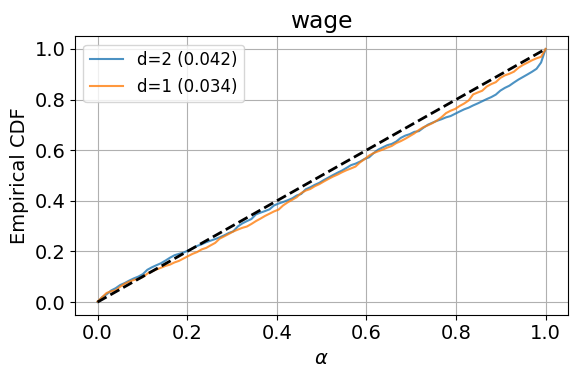

In [45]:
alphas = np.linspace(0, 1, 100)
sorted_indices = torch.argsort(pce_total, descending=True)  # or ascending=False

plt.figure(figsize=(6, 4))
for rank, d in enumerate(sorted_indices):
    d = d.item()
    cdf = cdfs_total[d].cpu().numpy()
    plt.plot(alphas, cdf, color=colors[rank], 
             lw=1.5, alpha=0.8, label=f"d={d+1} ({pce_total[d]:.3f})")

plt.plot(alphas, alphas, linestyle='--', color='black')
plt.xlabel(r"$\alpha$")
plt.ylabel("Empirical CDF")
plt.title(f"{data_name}")
plt.grid(True)
plt.tight_layout()
plt.legend(loc = 'upper left')
filename = f"figures/paper/{data_name}/rel_plot_{prerank}_{data_name}_mixgauss_trained_on_marginal_{model.hparams.prerank}.png"
plt.savefig(filename, bbox_inches = 'tight', dpi=500)
plt.show()

#### Making box plots for PCE, NLL, Energy Score, MSE before and after reg (with prerank only for now)

In [54]:
sns.set_style("whitegrid")

In [55]:
df = pd.read_csv('metrics-after-reg-ansur-taxi.csv') #without calcofi, rf1, rf2, sf2
df.head()

,data_name,seed,prerank,pce,nll,energy,mse
0,households,0,marginal,0.028741,3.295859,0.951055,0.663382
1,households,42,marginal,0.031749,3.270183,0.882693,0.554523
2,households,866,marginal,0.029671,3.396923,0.965792,0.652964
3,households,12,marginal,0.029982,3.423873,0.960883,0.667672
4,households,4,marginal,0.027437,3.255520,0.935410,0.623558


In [56]:
avg_df = df.groupby(['data_name', 'prerank'], sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_df = avg_df[~avg_df['data_name'].isin(['rf1', 'rf2', 'sf2'])]
avg_df.head(10)

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.029516,3.328471,0.939167,0.632420
1,households,mean,0.023898,3.395145,0.944452,0.628032
2,households,variance,0.021100,3.335899,0.936779,0.634394
3,households,dependency,0.020640,3.228757,0.921436,0.619659
4,households,pca,0.025954,3.330700,0.937192,0.621929
5,households,density,0.038680,3.292781,0.932650,0.628786
6,households,cdf,0.030640,3.354427,0.952433,0.658789
7,air,marginal,0.039892,5.798495,1.421109,0.950752
8,air,mean,0.026328,5.812055,1.427127,0.949652
9,air,variance,0.026756,5.750404,1.417962,0.956134


In [62]:
df_before = pd.read_csv('metrics-before-reg.csv')
df_before = df_before[~df_before['data_name'].isin(['rf1', 'rf2', 'sf2'])]
df_before.head(10)

,data_name,seed,prerank,pce,nll,energy,mse
0,households,0,marginal,0.089804,3.234141,0.933722,0.648897
1,households,0,mean,0.089603,3.234141,0.932309,0.648897
2,households,0,variance,0.145472,3.234141,0.932362,0.648897
3,households,0,dependency,0.016523,3.234141,0.937315,0.648897
4,households,0,pca,0.066246,3.234141,0.934260,0.648897
5,households,0,density,0.122928,3.234141,0.935134,0.648897
6,households,0,cdf,0.142132,3.234141,0.935170,0.648897
7,households,42,marginal,0.105159,3.045737,0.867218,0.529999
8,households,42,mean,0.098996,3.045737,0.863665,0.529999
9,households,42,variance,0.111250,3.045737,0.870574,0.529999


In [64]:
avg_scores_per_seed = df_before.groupby(['data_name', 'prerank'], sort = False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
# avg_scores_per_data = avg_scores_per_seed.groupby('data_name', sort=False)[['nll', 'energy', 'mse']].mean().reset_index()
avg_scores_per_seed.head(8)


,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.094671,3.187087,0.917795,0.614488
1,households,mean,0.091937,3.187087,0.917843,0.614488
2,households,variance,0.125329,3.187087,0.919684,0.614488
3,households,dependency,0.021782,3.187087,0.919045,0.614488
4,households,pca,0.066102,3.187087,0.918087,0.614488
5,households,density,0.097097,3.187087,0.917767,0.614488
6,households,cdf,0.149487,3.187087,0.916933,0.614488
7,air,marginal,0.099014,5.650568,1.397020,0.937892


In [14]:
avg_scores_per_data['prerank'] = 'none'
avg_scores_per_data['pce'] = 0
avg_scores_per_data.head()

,data_name,nll,energy,mse,prerank,pce
0,households,3.187087,0.918165,0.614488,none,0
1,air,5.650568,1.397655,0.937892,none,0
2,births1,1.181293,0.682644,0.759425,none,0
3,births2,-4.447253,0.922516,1.067480,none,0
4,wage,0.511141,0.711580,0.727497,none,0


In [16]:
combined_df = pd.concat([avg_df, avg_scores_per_data], ignore_index=True)
combined_df.head(10)

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.029516,3.328471,0.939167,0.632420
1,households,mean,0.023898,3.395145,0.944452,0.628032
2,households,variance,0.021100,3.335899,0.936779,0.634394
3,households,dependency,0.020640,3.228757,0.921436,0.619659
4,households,pca,0.025954,3.330700,0.937192,0.621929
5,households,density,0.038680,3.292781,0.932650,0.628786
6,households,cdf,0.030640,3.354427,0.952433,0.658789
7,air,marginal,0.039892,5.798495,1.421109,0.950752
8,air,mean,0.026328,5.812055,1.427127,0.949652
9,air,variance,0.026756,5.750404,1.417962,0.956134


In [17]:
combined_df[combined_df['data_name']=='households']

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.029516,3.328471,0.939167,0.632420
1,households,mean,0.023898,3.395145,0.944452,0.628032
2,households,variance,0.021100,3.335899,0.936779,0.634394
3,households,dependency,0.020640,3.228757,0.921436,0.619659
4,households,pca,0.025954,3.330700,0.937192,0.621929
5,households,density,0.038680,3.292781,0.932650,0.628786
6,households,cdf,0.030640,3.354427,0.952433,0.658789
119,households,none,0.000000,3.187087,0.918165,0.614488


In [57]:
plt.rcParams.update({'font.size': 10})

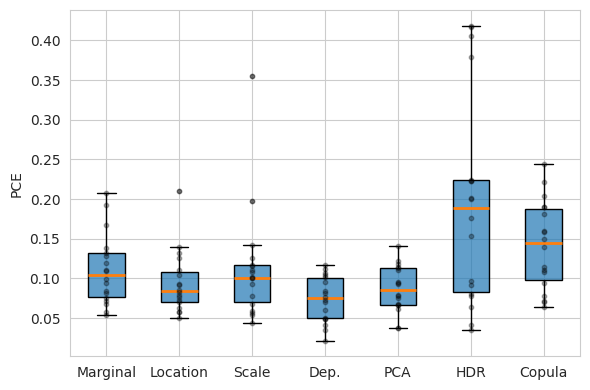

In [66]:
preranks = avg_scores_per_seed['prerank'].unique()

data = [avg_scores_per_seed[avg_scores_per_seed['prerank'] == p]['pce'].values for p in preranks]

plt.figure(figsize=(6, 4))

flierprops = dict(marker='o', markerfacecolor='black', markeredgecolor='black', markersize=3, linestyle='none', alpha=0.3) #outliers
box = plt.boxplot(data, tick_labels=["Marginal", "Location", "Scale", "Dep.", "PCA", "HDR", "Copula"], 
                  patch_artist=True, flierprops=flierprops, meanline = True)

for patch in box['boxes']:
    patch.set_facecolor((31/255, 119/255, 180/255, 0.7)) 
    # patch.set_edgecolor("#9673A6")
#color for NLL (opaque red) --> (227/255, 119/255, 119/255, 0.3)
#colors for Energy (opaque green) --> (44/255, 160/255, 44/255, 0.3)
# for whisker in box['whiskers']:
#     whisker.set_color('#9673A6')  
#     whisker.set_linewidth(1.5)   

# for cap in box['caps']:
#     cap.set_color('#9673A6')
#     cap.set_linewidth(1.5)

for median in box['medians']:
    median.set_linewidth(2)
# box['medians'][-1].set_color("#1a9012")
for i, p in enumerate(data):
    x = [i + 1] * len(p)
    plt.scatter(x, p, color='black', s=10, zorder=3, alpha = 0.3)

plt.ylabel("PCE")
plt.tight_layout()
plt.savefig(f"figures/paper/box_plot_before_pce.png", bbox_inches='tight', dpi=500)
plt.show()

In [4]:
df_before = pd.read_csv('metrics-before-reg.csv')
df_before.head()

,data_name,seed,prerank,pce,nll,energy,mse
0,households,0,marginal,0.089804,3.234141,0.933722,0.648897
1,households,0,mean,0.089603,3.234141,0.932309,0.648897
2,households,0,variance,0.145472,3.234141,0.932362,0.648897
3,households,0,dependency,0.016523,3.234141,0.937315,0.648897
4,households,0,pca,0.066246,3.234141,0.934260,0.648897


In [37]:
avg_df_before = df_before.groupby(['data_name', 'prerank'], sort=False)[['pce', 'nll', 'energy', 'mse']].mean().reset_index()
avg_df_before.head(10)

,data_name,prerank,pce,nll,energy,mse
0,households,marginal,0.094671,3.187087,0.917795,0.614488
1,households,mean,0.091937,3.187087,0.917843,0.614488
2,households,variance,0.125329,3.187087,0.919684,0.614488
3,households,dependency,0.021782,3.187087,0.919045,0.614488
4,households,pca,0.066102,3.187087,0.918087,0.614488
5,households,density,0.097097,3.187087,0.917767,0.614488
6,households,cdf,0.149487,3.187087,0.916933,0.614488
7,air,marginal,0.099014,5.650568,1.397020,0.937892
8,air,mean,0.092714,5.650568,1.396897,0.937892
9,air,variance,0.198090,5.650568,1.400152,0.937892


In [40]:
grouped = avg_df_before.groupby("data_name")[["nll", "energy", "mse"]].mean().reset_index()
grouped = grouped[~grouped['data_name'].isin(['rf1', 'rf2', 'sf2'])]

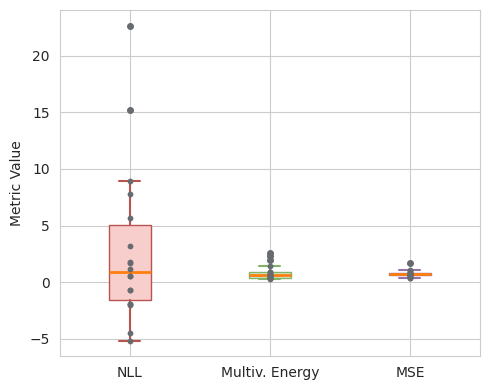

In [ ]:
plt.figure(figsize=(5, 4))

flierprops = dict(marker='o', markerfacecolor='#6C8EBF', markeredgecolor='#676B70', markersize=4, linestyle='none') #outliers
box = plt.boxplot([grouped[col].values for col in ["nll", "energy", "mse"]],
                  patch_artist=True, tick_labels=["NLL", "Multiv. Energy", "MSE"], flierprops=flierprops)

for patch in box['boxes']:
    patch.set_facecolor("#DAE8FC")
    patch.set_edgecolor("#6C8EBF")

colors = ['#F8CECC', '#D5E8D4', '#E1D5E7']  # one color per box
edge_colors = ['#B85450', "#82B366", "#9673A6"]
for patch, color, edge in zip(box['boxes'], colors, edge_colors):
    patch.set_facecolor(color)
    patch.set_edgecolor(edge)  # optional

for median in box['medians']:
    median.set_linewidth(2)

for i, edge in enumerate(edge_colors):
    box['caps'][2*i].set_color(edge)     # bottom cap
    box['caps'][2*i + 1].set_color(edge) # top cap
    box['caps'][2*i].set_linewidth(1.5)
    box['caps'][2*i+1].set_linewidth(1.5)

for i, edge in enumerate(edge_colors):
    box['whiskers'][2*i].set_color(edge)     
    box['whiskers'][2*i + 1].set_color(edge) 
    box['whiskers'][2*i].set_linewidth(1.5)
    box['whiskers'][2*i+1].set_linewidth(1.5)


for i, col in enumerate(["nll", "energy", "mse"]):
    plt.scatter([i + 1] * len(grouped), grouped[col].values, color='#676B70', s=10, zorder=3)

plt.ylabel("Metric Value")
plt.tight_layout()
plt.savefig(f"figures/paper/box_plot_before_scores.png", bbox_inches='tight', dpi=500)
plt.show()

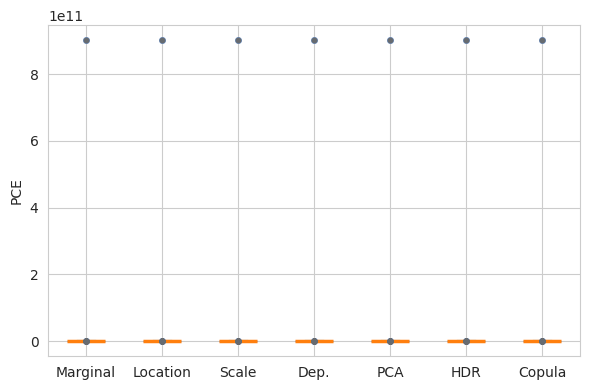

In [ ]:
preranks = avg_df_before['prerank'].unique()
data = [avg_df_before[avg_df_before['prerank'] == p]['nll'].values for p in preranks]

plt.figure(figsize=(6, 4))

flierprops = dict(marker='o', markerfacecolor='#6C8EBF', markeredgecolor='#6C8EBF', markersize=4, linestyle='none') #outliers
box = plt.boxplot(data, tick_labels=["Marginal", "Location", "Scale", "Dep.", "PCA", "HDR", "Copula"], 
                  patch_artist=True, flierprops=flierprops, meanline = True)

for patch in box['boxes']:
    patch.set_facecolor("#DAE8FC")  
    patch.set_edgecolor("#6C8EBF")

for whisker in box['whiskers']:
    whisker.set_color('#6C8EBF')  
    whisker.set_linewidth(1.5)   

for cap in box['caps']:
    cap.set_color('#6C8EBF')
    cap.set_linewidth(1.5)

for median in box['medians']:
    median.set_linewidth(2.5)

for i, p in enumerate(data):
    x = [i + 1] * len(p)
    plt.scatter(x, p, color='#676B70', s=10, zorder=3)

plt.ylabel("PCE")
plt.tight_layout()
# plt.savefig(f"figures/paper/box_plot_before.png", bbox_inches='tight', dpi=500)
plt.show()